# LLM Adversary Evaluation

Tests the **AdaptiveAgent** against an out-of-distribution adversary: a GPT LLM playing Liar's Dice
with the same partial information any other agent receives (own dice + public state).

The LLM accumulates a compact summary of all previous rounds **within the same game**, giving it
within-game memory while staying comparable to the AdaptiveAgent.

**Sections:**
1. Setup & imports
2. Game loop helpers
3. Agent initialisation
4. Test game — one full match, verbose
5. Aggregated run — 50 games
6. Results & belief tracker analysis
7. Baseline comparison

## 1. Setup & Imports

In [1]:
import sys
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Notebook lives in scripts/ — repo root is one level up
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
print(f"Repo root: {REPO_ROOT}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("Libraries imported.")

Repo root: C:\Users\shaha\Work\Personal\AIGT\Adaptive-Strategy-Learning-in-Liar-s-Dice
Libraries imported.


In [8]:
# -- OpenAI config ----------------------------------------------------------
# Reads from env var if set; otherwise prompts at runtime.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY") or input("OpenAI API key: ")

try:
    from openai import OpenAI
    _oai_client = OpenAI(api_key=OPENAI_API_KEY)
    print("OpenAI client ready")
except ImportError:
    print("openai package not found. Run: pip install openai")
    _oai_client = None

# -- Experiment config -------------------------------------------------------
NUM_GAMES  = 50
TOTAL_DICE = 5

# -- Agents to evaluate ------------------------------------------------------
# temperature is only sent for gpt-4o* / gpt-4.1* families; ignored otherwise.
AGENTS_CONFIG = [
    {"label": "gpt-4o-mini",  "model": "gpt-4o-mini",  "temperature": 0.7},  # older, chat
    {"label": "gpt-4.1-mini", "model": "gpt-4.1-mini", "temperature": 0.7},  # newer, instruction-following
    {"label": "gpt-5.4-nano", "model": "gpt-5.4-nano"},                       # GPT-5.4 lightweight
]
print(f"Evaluating {len(AGENTS_CONFIG)} agent(s): {[c['label'] for c in AGENTS_CONFIG]}")

OpenAI client ready
Evaluating 3 agent(s): ['gpt-4o-mini', 'gpt-4.1-mini', 'gpt-5.4-nano']


In [4]:
from liars_dice.core.config    import GameConfig
from liars_dice.core.engine    import GameEngine
from liars_dice.agents.adaptive_agent import AdaptiveAgent
from liars_dice.agents.bayesian_agent import BayesianAgent
from liars_dice.agents.llm_agent      import LLMAdversaryAgent

# rng_seed=None seeds from the system clock, so each GameEngine gets
# independently rolled dice. A fixed seed makes every game a replay of the same rolls.
GAME_CONFIG = GameConfig(
    num_players=2,
    total_dice=TOTAL_DICE,
    faces=(1, 2, 3, 4, 5, 6),
    ones_wild=False,
    rng_seed=None,
)
print("Game config:", GAME_CONFIG)

Game config: GameConfig(num_players=2, total_dice=5, dice_distribution=None, faces=(1, 2, 3, 4, 5, 6), ones_wild=False, bid_ordering='quantity_then_face', allow_opening_bid_constraints=False, max_turns=64, rng_seed=None)


## 2. Game Loop Helpers

In [9]:
from liars_dice.agents.llm_agent import LLMResponseError


def play_single_round(engine: GameEngine, agents: list) -> dict:
    """
    Purpose: Run one complete round of Liar's Dice to termination.
    Method: Alternate turns, call choose_action, apply_action; collect events.
            If an agent raises LLMResponseError (illegal / unparseable action)
            the offending player forfeits the round immediately.

    Args:
        engine (GameEngine): Initialised engine with start_new_round() already called.
        agents (list): [agent_for_player_0, agent_for_player_1].

    Returns:
        dict: {winner, loser, num_turns, was_true, bid_history}.
    """
    all_events = []
    num_turns  = 0

    while not engine.is_terminal():
        current = engine.state.public.current_player
        view    = engine.get_view(current)
        try:
            action = agents[current].choose_action(view)
        except LLMResponseError as e:
            # Illegal / unparseable LLM action — that player forfeits the round
            return {
                "winner":      1 - current,
                "loser":       current,
                "num_turns":   num_turns,
                "was_true":    False,
                "bid_history": list(engine.state.public.bid_history),
            }
        engine.apply_action(current, action)
        all_events.extend(engine.pop_events())
        num_turns += 1

    was_true = next(
        (e["was_true"] for e in all_events if e["type"] == "RoundEnded"), None
    )

    return {
        "winner":      engine.state.public.winner,
        "loser":       engine.state.public.loser,
        "num_turns":   num_turns,
        "was_true":    was_true,
        "bid_history": list(engine.state.public.bid_history),
    }


def play_match(adaptive: AdaptiveAgent, llm: LLMAdversaryAgent,
               config: GameConfig, adaptive_is_p0: bool) -> dict:
    """
    Purpose: Run one full match (dice-elimination) between AdaptiveAgent and LLM.
    Method: Multi-round loop; loser drops a die each round until someone hits 0.
            Calls llm.record_round() after each round to update within-game memory.

    Args:
        adaptive (AdaptiveAgent): Our trained adaptive agent.
        llm (LLMAdversaryAgent): The LLM adversary.
        config (GameConfig): Game configuration.
        adaptive_is_p0 (bool): Whether AdaptiveAgent plays as player 0.

    Returns:
        dict: {adaptive_won, rounds_played, belief_history, final_belief}.
    """
    adaptive.reset()
    llm.reset()

    agents         = [adaptive, llm] if adaptive_is_p0 else [llm, adaptive]
    llm_pid        = 1 if adaptive_is_p0 else 0
    adaptive_pid   = 1 - llm_pid
    engine         = GameEngine(config)
    dice_counts    = list(config.dice_distribution or (config.total_dice, config.total_dice))
    belief_history = []
    rounds_played  = 0

    while True:
        for i in range(2):
            engine.state.players[i].num_dice = dice_counts[i]

        llm_dice_before = dice_counts[llm_pid]
        opp_dice_before = dice_counts[adaptive_pid]

        engine.start_new_round()
        engine.pop_events()

        round_result = play_single_round(engine, agents)
        rounds_played += 1
        belief_history.append(adaptive.get_belief_summary())

        llm.record_round(
            bid_history = round_result["bid_history"],
            my_dice     = llm_dice_before,
            opp_dice    = opp_dice_before,
            i_won       = round_result["winner"] == llm_pid,
            was_true    = round_result["was_true"],
        )

        loser = round_result["loser"]
        if loser is not None:
            dice_counts[loser] -= 1

        if dice_counts[0] <= 0 or dice_counts[1] <= 0:
            winner_pid = 0 if dice_counts[0] > 0 else 1
            return {
                "adaptive_won":   winner_pid == adaptive_pid,
                "rounds_played":  rounds_played,
                "belief_history": belief_history,
                "final_belief":   belief_history[-1],
            }


print("Game loop helpers defined.")

Game loop helpers defined.


## 3. Agent Initialisation

In [10]:
from liars_dice.agents.adaptive_agent import AdaptiveAgent
from liars_dice.agents.llm_agent      import LLMAdversaryAgent

adaptive_agent = AdaptiveAgent(device="cpu")

AGENTS_TO_EVAL = [
    (cfg["label"], LLMAdversaryAgent(
        client      = _oai_client,
        model       = cfg["model"],
        temperature = cfg.get("temperature", 0.7),
        verbose     = False,
    ))
    for cfg in AGENTS_CONFIG
]

# expose first agent as llm_agent so the test-game cell works unchanged
llm_agent = AGENTS_TO_EVAL[0][1]

print("AdaptiveAgent loaded.")
for label, _ in AGENTS_TO_EVAL:
    print(f"  LLM adversary: {label}")

AdaptiveAgent loaded.
  LLM adversary: gpt-4o-mini
  LLM adversary: gpt-4.1-mini
  LLM adversary: gpt-5.4-nano


## 4. Smoke Test — 1 Game per Agent

Quick connectivity check before committing to 50 games. Runs one full match per agent and reports PASS / FAIL.

In [11]:
import traceback

print("Smoke test — 1 game per agent")
print("=" * 45)
all_ok = True

for label, llm_i in AGENTS_TO_EVAL:
    t0 = time.time()
    try:
        r = play_match(adaptive_agent, llm_i, GAME_CONFIG, adaptive_is_p0=True)
        elapsed = time.time() - t0
        winner  = "AdaptiveAgent" if r["adaptive_won"] else label
        print(f"  PASS  {label:<16} {r['rounds_played']} rounds  winner={winner}  ({elapsed:.1f}s)")
    except Exception as e:
        elapsed = time.time() - t0
        print(f"  FAIL  {label:<16} {e}  ({elapsed:.1f}s)")
        traceback.print_exc()
        all_ok = False

print("=" * 45)
print("All agents OK — proceed to aggregated run." if all_ok else
      "Some agents failed — fix before running 50 games.")

Smoke test — 1 game per agent
  PASS  gpt-4o-mini      7 rounds  winner=AdaptiveAgent  (9.0s)
  PASS  gpt-4.1-mini     5 rounds  winner=AdaptiveAgent  (3.1s)
  PASS  gpt-5.4-nano     6 rounds  winner=AdaptiveAgent  (11.3s)
All agents OK — proceed to aggregated run.


## 4. Aggregated Run — 50 Games

In [14]:
all_results = {}   # label -> DataFrame

for label, llm_i in AGENTS_TO_EVAL:
    results = []
    wins    = 0
    pbar = tqdm(range(NUM_GAMES), desc=label, unit="game", leave=True)

    for game_idx in pbar:
        adaptive_is_p0 = (game_idx % 2 == 0)

        result       = play_match(adaptive_agent, llm_i, GAME_CONFIG,
                                  adaptive_is_p0=adaptive_is_p0)
        final_belief = result["final_belief"]
        top_label    = (
            max(final_belief["beliefs"], key=final_belief["beliefs"].get)
            if final_belief["beliefs"] else "generalist"
        )

        if result["adaptive_won"]:
            wins += 1

        results.append({
            "game":              game_idx,
            "adaptive_is_p0":   adaptive_is_p0,
            "adaptive_won":     result["adaptive_won"],
            "rounds_played":    result["rounds_played"],
            "using_generalist": final_belief["using_generalist"],
            "top_label":        top_label,
            "top_belief":       final_belief["beliefs"].get(top_label, 0.0),
        })

        played = game_idx + 1
        pbar.set_postfix(
            adaptive_wins=f"{wins}/{played}",
            win_rate=f"{wins/played:.0%}",
            rounds=str(result["rounds_played"]),
        )

    all_results[label] = pd.DataFrame(results)
    print(f"{label}: AdaptiveAgent won {wins}/{NUM_GAMES} ({wins/NUM_GAMES:.1%})")

gpt-4o-mini:   0%|          | 0/50 [00:00<?, ?game/s]

gpt-4o-mini: AdaptiveAgent won 26/50 (52.0%)


gpt-4.1-mini:   0%|          | 0/50 [00:00<?, ?game/s]

gpt-4.1-mini: AdaptiveAgent won 47/50 (94.0%)


gpt-5.4-nano:   0%|          | 0/50 [00:00<?, ?game/s]

gpt-5.4-nano: AdaptiveAgent won 47/50 (94.0%)


## 5. Results & Belief Analysis

In [15]:
from scipy.stats import norm as _norm

def wilson_ci(wins, n, z=_norm.ppf(0.975)):
    """Wilson 95% confidence interval for a proportion."""
    p = wins / n
    lo = (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    hi = (p + z**2/(2*n) + z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    return lo, hi

for label, df in all_results.items():
    n_wins  = df["adaptive_won"].sum()
    n_total = len(df)
    wr      = n_wins / n_total
    lo, hi  = wilson_ci(n_wins, n_total)

    print("=" * 55)
    print(f"AdaptiveAgent vs {label}")
    print(f"  Games:    {n_total}")
    print(f"  Win rate: {wr:.1%}  (95% CI: [{lo:.1%}, {hi:.1%}])")
    for pos, pos_label in [(True, "as P0"), (False, "as P1")]:
        sub = df[df['adaptive_is_p0'] == pos]
        print(f"  Win rate {pos_label}: {sub['adaptive_won'].mean():.1%}  (n={len(sub)})")
    print(f"  Rounds/match — mean: {df['rounds_played'].mean():.1f}  "
          f"median: {df['rounds_played'].median():.0f}  max: {df['rounds_played'].max()}")
    gen_pct = df["using_generalist"].mean()
    print(f"  Generalist fallback: {gen_pct:.1%}  "
          f"| Mean top-belief: {df['top_belief'].mean():.3f}")
print("=" * 55)

AdaptiveAgent vs gpt-4o-mini
  Games:    50
  Win rate: 52.0%  (95% CI: [38.5%, 65.2%])
  Win rate as P0: 56.0%  (n=25)
  Win rate as P1: 48.0%  (n=25)
  Rounds/match — mean: 7.7  median: 8  max: 9
  Generalist fallback: 100.0%  | Mean top-belief: 0.042
AdaptiveAgent vs gpt-4.1-mini
  Games:    50
  Win rate: 94.0%  (95% CI: [83.8%, 97.9%])
  Win rate as P0: 100.0%  (n=25)
  Win rate as P1: 88.0%  (n=25)
  Rounds/match — mean: 7.1  median: 7  max: 9
  Generalist fallback: 100.0%  | Mean top-belief: 0.042
AdaptiveAgent vs gpt-5.4-nano
  Games:    50
  Win rate: 94.0%  (95% CI: [83.8%, 97.9%])
  Win rate as P0: 92.0%  (n=25)
  Win rate as P1: 96.0%  (n=25)
  Rounds/match — mean: 6.9  median: 7  max: 9
  Generalist fallback: 100.0%  | Mean top-belief: 0.042


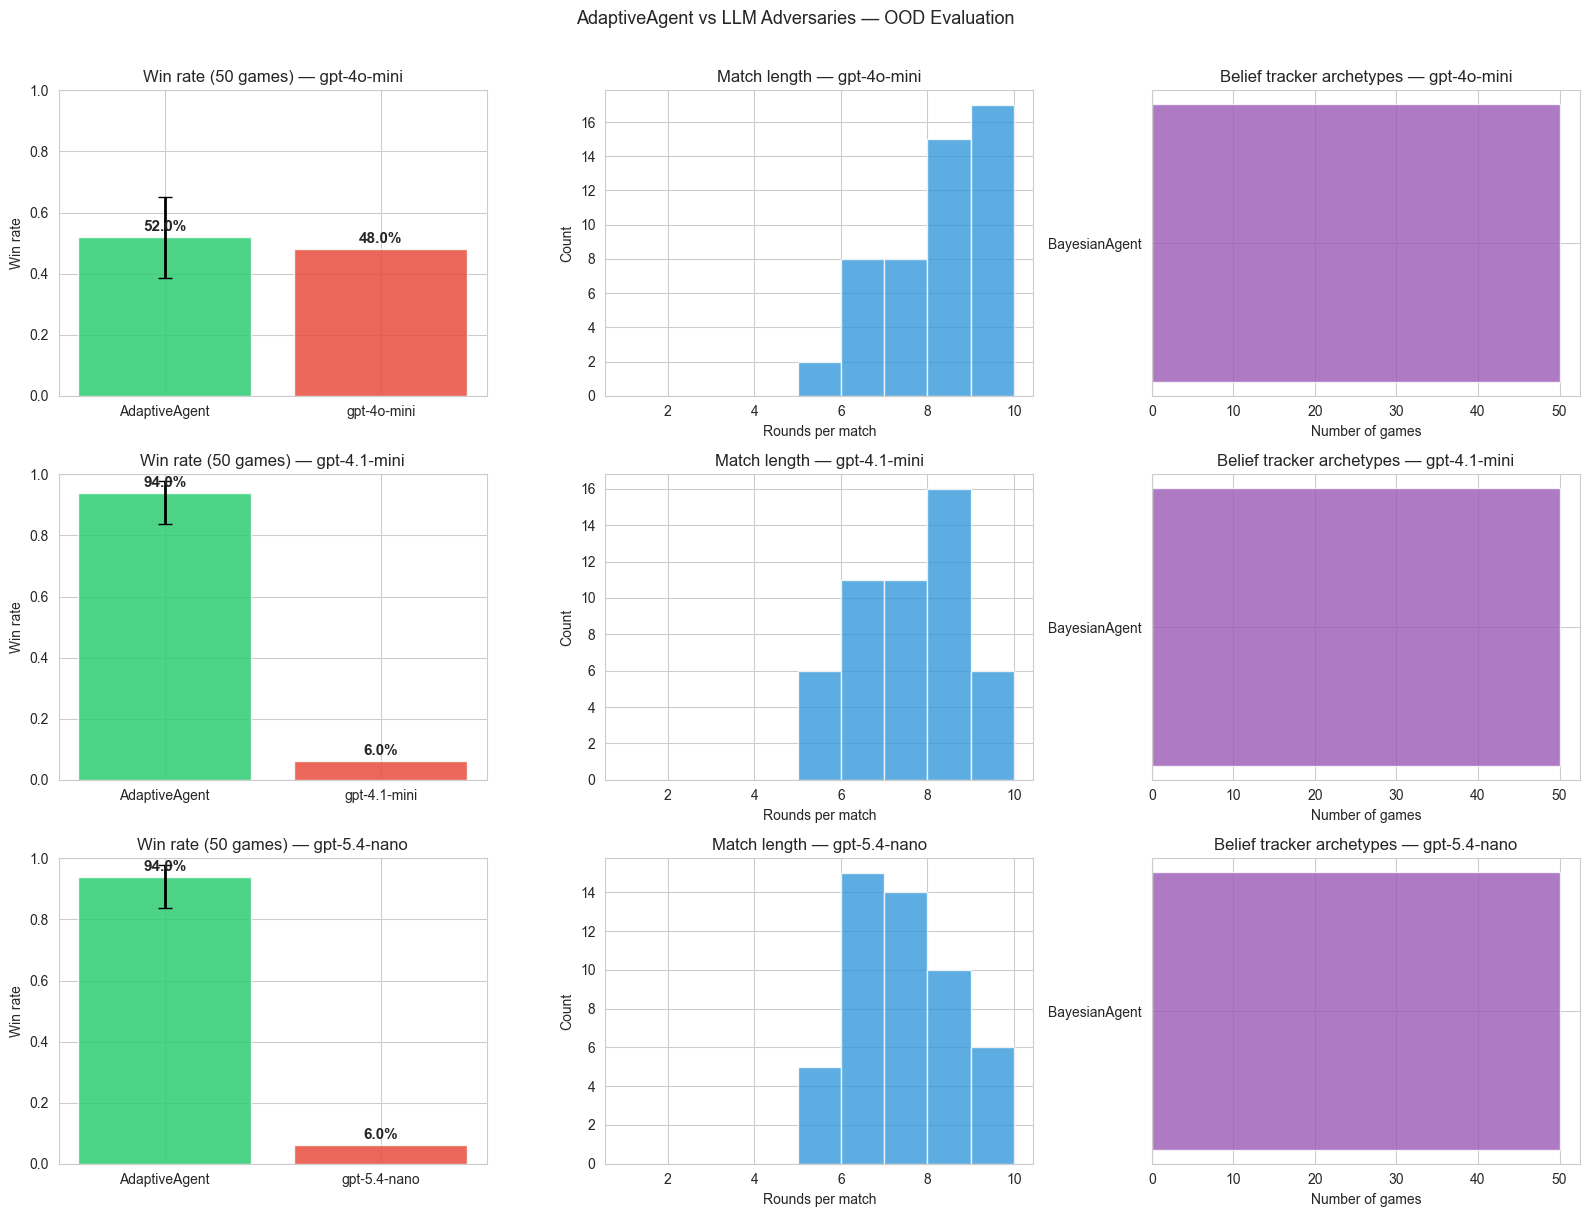

In [16]:
n_agents = len(all_results)
fig, axes = plt.subplots(n_agents, 3, figsize=(16, 4 * n_agents),
                         squeeze=False)  # always 2-D axes array

for row, (label, df) in enumerate(all_results.items()):
    n_wins  = df["adaptive_won"].sum()
    n_total = len(df)
    wr      = n_wins / n_total
    lo, hi  = wilson_ci(n_wins, n_total)

    # col 0: win rate bar
    ax   = axes[row, 0]
    bars = ax.bar(["AdaptiveAgent", label], [wr, 1 - wr],
                  color=["#2ecc71", "#e74c3c"], alpha=0.85)
    ax.errorbar([0], [wr], yerr=[[wr - lo], [hi - wr]], fmt="none",
                color="black", capsize=5, linewidth=2)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Win rate")
    ax.set_title(f"Win rate ({n_total} games) — {label}")
    for bar, val in zip(bars, [wr, 1 - wr]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")

    # col 1: match length histogram
    ax = axes[row, 1]
    ax.hist(df["rounds_played"],
            bins=range(1, df["rounds_played"].max() + 2),
            color="#3498db", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Rounds per match")
    ax.set_ylabel("Count")
    ax.set_title(f"Match length — {label}")

    # col 2: belief tracker top archetypes
    ax         = axes[row, 2]
    top_labels = df["top_label"].value_counts().head(8)
    ax.barh(top_labels.index[::-1], top_labels.values[::-1],
            color="#9b59b6", alpha=0.8)
    ax.set_xlabel("Number of games")
    ax.set_title(f"Belief tracker archetypes — {label}")

plt.suptitle("AdaptiveAgent vs LLM Adversaries — OOD Evaluation",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()